In [86]:
# python v3.10.11
# import necessary packages

import os
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore')

import pandas as pd

from matplotlib.colors import LogNorm
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm


%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
# set directory and get relevant files

os.chdir('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\model_outputs\\')
death_pvals = pd.read_excel('death_classifier_probes.xlsx', index_col=0)
pinv_pvals = pd.read_excel('pseudoinverse_probes_filtered.xlsx', index_col=0)

In [88]:
# unfiltered probes
all_probes = pinv_pvals
all_probes = all_probes.dropna()
all_probes = list(all_probes.index)
print(f'Number of total probes: {len(all_probes)}')

# m14 blood glucose probes
GLU_probes_M14 = pinv_pvals['M14_poststress_GLU_pval']
GLU_probes_M14 = GLU_probes_M14.dropna()
GLU_probes_M14 = GLU_probes_M14[GLU_probes_M14 < 0.01]
GLU_probes_M14 = list(GLU_probes_M14.index)
print(f'Number of m14 blood glucose probes: {len(GLU_probes_M14)}')

# aging probes
age_probes = death_pvals
age_probes = age_probes.dropna()
age_probes = list(age_probes.index)
print(f'Number of aging probes: {len(age_probes)}')

##

glu_intersections = list(set(GLU_probes_M14) & set(age_probes))

all_cross = death_pvals.loc[glu_intersections]
all_cross = all_cross[['coef', 'associated_genes']]
all_cross = all_cross.rename_axis('ID').reset_index()
print(f'Number of probes intersected between blood glucose and aging: {len(all_cross)}')

Number of total probes: 7594
Number of m14 blood glucose probes: 58
Number of aging probes: 9363
Number of probes intersected between blood glucose and aging: 23


In [89]:
'''
Define functions for plot generation
'''

# extract genes from associated_genes column
def extract_genes(gene_string):
    genes = []
    n_genes = gene_string.count(', ')
    n = 0
    while n < n_genes + 1:
        index_space = gene_string.find(' ')
        gene_n = gene_string[:index_space]
        genes.append(gene_n)
        index_comma = gene_string.find(', ')
        gene_string = gene_string[index_comma + 2:]
        n += 1
    return genes

# apply the function to each entry in 'associated_genes' column
def apply_gene_extraction(cross_identified_probes):
    associated_genes_full = [gene for gene in cross_identified_probes['associated_genes']]
    cross_identified_probes['genes'] = cross_identified_probes['associated_genes'].apply(extract_genes)

    # Count occurrences of each gene across all entries
    gene_counts = pd.Series([gene for genes_list in cross_identified_probes['genes'] for gene in genes_list]).value_counts()
    return associated_genes_full, gene_counts

def define_marker_style(cross_identified_probes, gene_counts):
    duplicates = gene_counts[gene_counts > 1].index.tolist()
    marker_style = []
    
    # Swapping markers logic: 'x' for duplicated genes, 'o' for non-duplicated genes
    for genes in cross_identified_probes['associated_genes']:
        to_append = 'o'  # default to 'o' (circle) for non-duplicated genes
        for gene in duplicates:
            if gene in genes:
                to_append = 'x'  # swap to 'x' for duplicated genes
        marker_style.append(to_append)

    #marker_style[0] = 'o' # for some reason seaborn bases how the marker_style list is interpreted by making the first character = dot

    return marker_style

# Function to plot scatter plot with dynamic data
def plot_scatter(ax, cross_identified_probes):
    associated_genes_full, gene_counts = apply_gene_extraction(cross_identified_probes)
    marker_style = define_marker_style(cross_identified_probes, gene_counts)

    sns.scatterplot(data=cross_identified_probes, x='coef', y='ID', style=marker_style, markers=['X', 'o'], s=200, 
                    legend=False, palette='viridis_d', hue='coef', ax=ax)

    # Add legend showing repeated genes
    props = dict(boxstyle='round', facecolor='green', alpha=0.5)
    gene_counts = gene_counts.to_dict()
    repeated = {key: value for key, value in gene_counts.items() if value > 1}
    gene_list_formatted = '\n'.join(f"{key} ({value}x)" for key, value in repeated.items())
    ax.text(0.03, 0.96, f'Duplicated Genes:\n\n{gene_list_formatted}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)

    # Annotate each point with associated genes
    for i, genes in enumerate(associated_genes_full):
        x = cross_identified_probes['coef'][i]
        y = cross_identified_probes.index[i]
        ax.annotate(genes, (x, y), textcoords="offset points", xytext=(10, -3), ha='left', size=9)

    ax.set_xlabel('elastic net coefficient', size=18)
    ax.set_ylabel('probes', size=18)
    ax.set_facecolor((1, 1, 0.8509803921))  # Same as plot included in same figure
    ax.set_xlim(-0.1, 0.3)

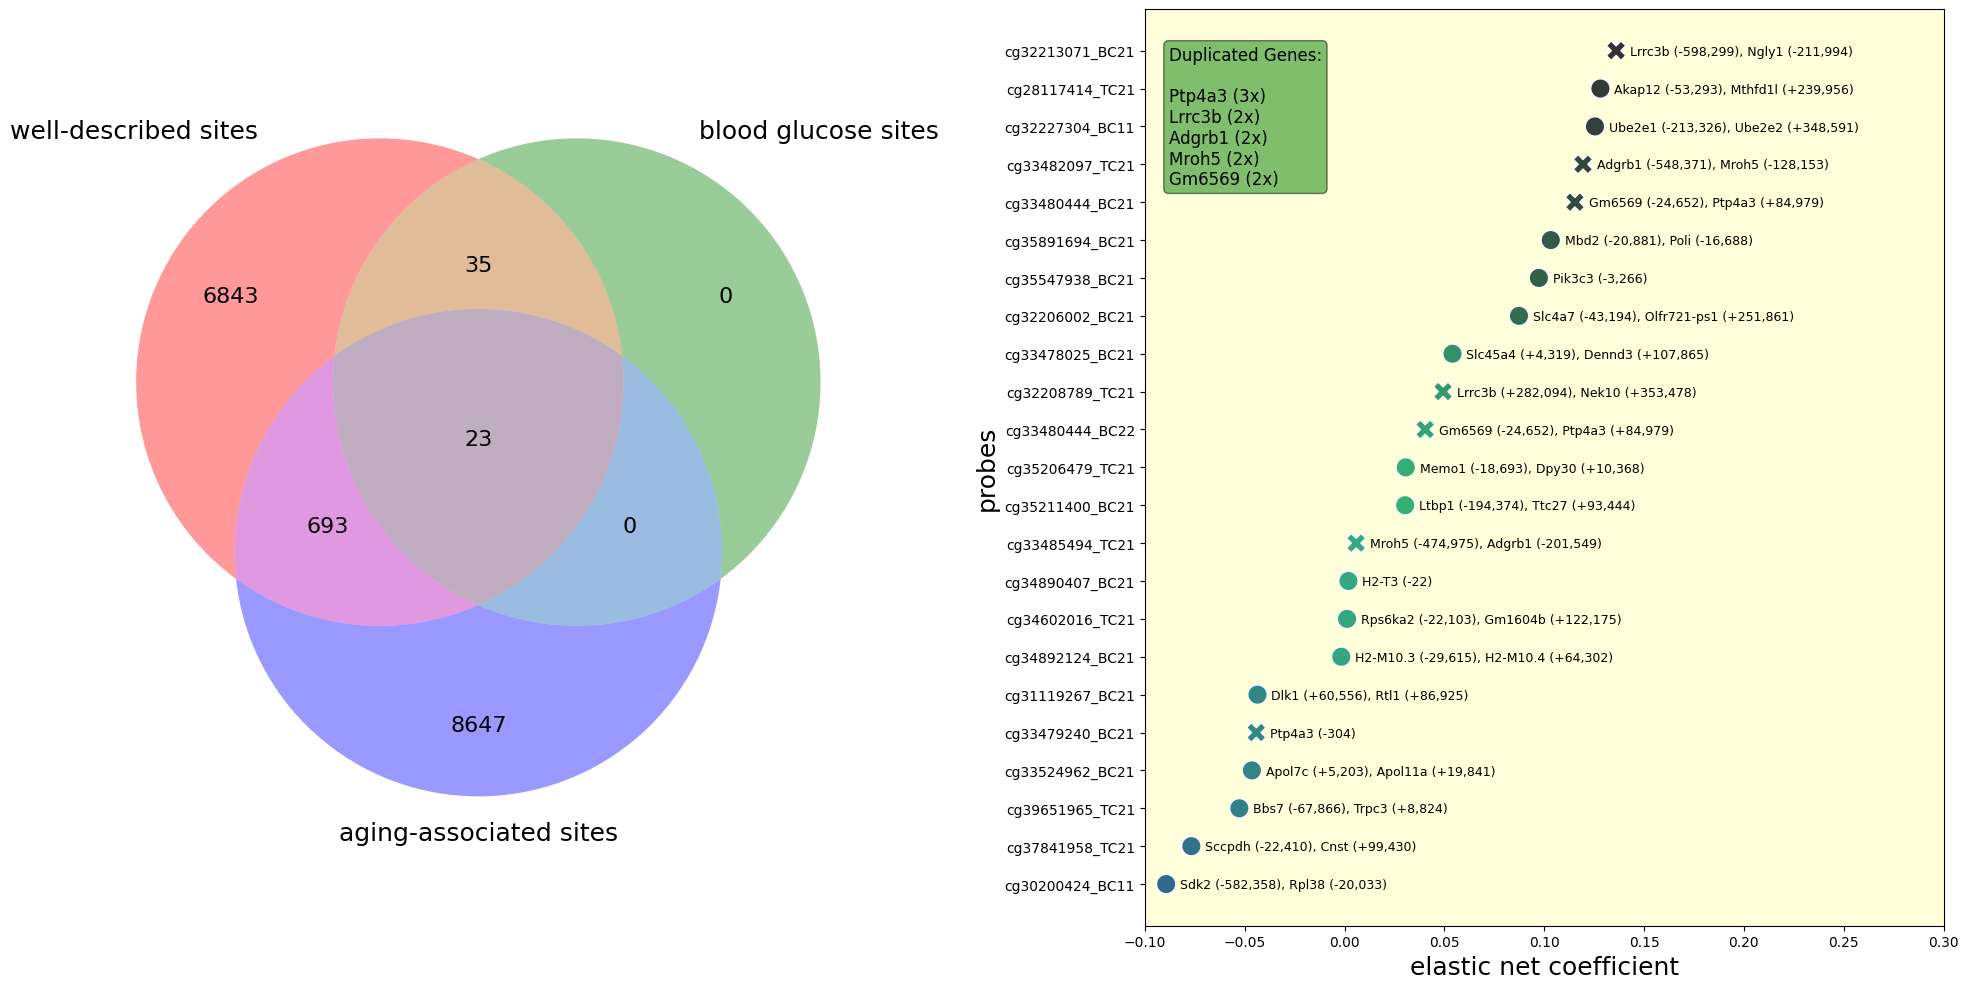

In [90]:
# Sort elastic net by value so the legend isn't obscured
cross_identified_probes = all_cross.sort_values(by='coef', ascending=False, ignore_index=True)

# Create 4 subplots (2x2 grid)
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # Adjust the figure size as needed


# plot 1
set1 = set(all_probes)      
set2 = set(GLU_probes_M14) 
set3 = set(age_probes)  

venn = venn3([set1, set2, set3], ('well-described sites', 'blood glucose sites', 'aging-associated sites'), ax=axs[0], layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)))

# adjust params
for text in venn.set_labels:
    text.set_fontsize(18)

for text in venn.subset_labels:
    text.set_fontsize(16) 

# plot 2
plot_scatter(axs[1], cross_identified_probes)
plt.tight_layout()

In [91]:
# print the probes intersected within the regions

print(all_cross)

                 ID      coef                          associated_genes
0   cg35206479_TC21  0.030675          Memo1 (-18,693), Dpy30 (+10,368)
1   cg39651965_TC21 -0.052675            Bbs7 (-67,866), Trpc3 (+8,824)
2   cg30200424_BC11 -0.089307          Sdk2 (-582,358), Rpl38 (-20,033)
3   cg33479240_BC21 -0.044193                             Ptp4a3 (-304)
4   cg34890407_BC21  0.001962                               H2-T3 (-22)
5   cg32227304_BC11  0.125424      Ube2e1 (-213,326), Ube2e2 (+348,591)
6   cg35547938_BC21  0.097336                           Pik3c3 (-3,266)
7   cg33478025_BC21  0.054077       Slc45a4 (+4,319), Dennd3 (+107,865)
8   cg35891694_BC21  0.103293            Mbd2 (-20,881), Poli (-16,688)
9   cg32208789_TC21  0.049347       Lrrc3b (+282,094), Nek10 (+353,478)
10  cg33480444_BC21  0.115388        Gm6569 (-24,652), Ptp4a3 (+84,979)
11  cg28117414_TC21  0.128155      Akap12 (-53,293), Mthfd1l (+239,956)
12  cg33524962_BC21 -0.046382        Apol7c (+5,203), Apol11a (+

In [92]:
# export food intake probes as table

ffm_cross.to_excel('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\model_outputs\\m16_ffm_aging_intersection.xlsx')